In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from statsmodels.stats.stattools import durbin_watson
from matplotlib.lines import Line2D
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.serif": ["Computer Modern"],
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 12,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,})

In [29]:
# Datos
f = np.array([0,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190])

Rb85 = np.array([0.310,0.416,0.443,0.466,0.491,0.512,
                 0.536,0.558,0.582,0.606,0.632,0.654,0.679,0.700,
                 0.724,0.747])

Rb87 = np.array([0.310,0.476,0.515,0.549,0.586,0.618,
                 0.653,0.688,0.724,0.757,0.797,0.831,0.867,0.901,
                 0.935,0.970])

# Incertidumbres
dI = 0.001
df = f * 1e-6      # AFG3022B ~ 1 ppm

In [30]:
# Ajustes lineales
fit85 = linregress(Rb85, f)
fit87 = linregress(Rb87, f)

m85, b85 = fit85.slope, fit85.intercept
m87, b87 = fit87.slope, fit87.intercept


# Residuos
res85 = f - (m85*Rb85 + b85)
res87 = f - (m87*Rb87 + b87)

r85 = res85 / np.std(res85, ddof=2)
r87 = res87 / np.std(res87, ddof=2)


# Razón de pendientes
ratio = max(m85, m87) / min(m85, m87)

dratio = ratio * np.sqrt(
    (fit85.stderr/m85)**2 +
    (fit87.stderr/m87)**2
)

In [31]:
# Resultados
print(f"Rb-85: m = {m85:.0f} ± {fit85.stderr:.0f} kHz/A")
print(f"R² = {fit85.rvalue**2:.4f}")
print(f"Durbin-Watson = {durbin_watson(res85):.2f}")

print()

print(f"Rb-87: m = {m87:.1f} ± {fit87.stderr:.1f} kHz/A")
print(f"R² = {fit87.rvalue**2:.4f}")
print(f"Durbin-Watson = {durbin_watson(res87):.2f}")

print()

print(f"Razón de pendientes = {ratio:.3f} ± {dratio:.3f}")


Rb-85: m = 429 ± 2 kHz/A
R² = 0.9996
Durbin-Watson = 1.92

Rb-87: m = 285.8 ± 0.9 kHz/A
R² = 0.9999
Durbin-Watson = 1.94

Razón de pendientes = 1.502 ± 0.009


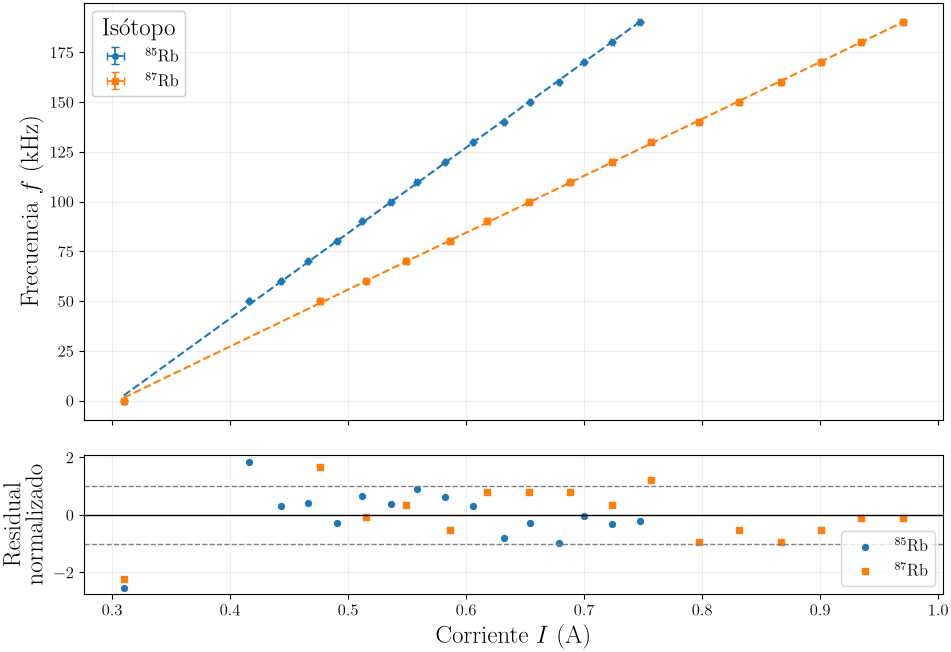

In [32]:
# Líneas del ajuste
x85 = np.linspace(Rb85.min(), Rb85.max(), 200)
x87 = np.linspace(Rb87.min(), Rb87.max(), 200)

# FIGURA 1

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10,7),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

# Rb-85
ax1.errorbar(
    Rb85, f,
    xerr=dI, yerr=df,
    fmt='o',
    markersize=4,
    color='tab:blue',
    ecolor='tab:blue',
    capsize=3,
    label=r'$^{85}$Rb'
)

ax1.plot(
    x85, m85*x85+b85,
    '--',
    color='tab:blue',
    linewidth=1.5
)

# Rb-87
ax1.errorbar(
    Rb87, f,
    xerr=dI, yerr=df,
    fmt='s',
    markersize=4,
    color='tab:orange',
    ecolor='tab:orange',
    capsize=3,
    label=r'$^{87}$Rb'
)

ax1.plot(
    x87, m87*x87+b87,
    '--',
    color='tab:orange',
    linewidth=1.5
)

ax1.set_ylabel('Frecuencia $f$ (kHz)')
ax1.grid(alpha=0.2)

# Leyenda de isótopos
legend1 = ax1.legend(title='Isótopo', loc='upper left')
ax1.add_artist(legend1)


# Residuales normalizados
ax2.scatter(
    Rb85, r85,
    s=18,
    color='tab:blue',
    marker='o',
    label=r'$^{85}$Rb'
)

ax2.scatter(
    Rb87, r87,
    s=18,
    color='tab:orange',
    marker='s',
    label=r'$^{87}$Rb'
)

ax2.axhline(0, color='black', linewidth=1)

ax2.axhline(
    1,
    color='gray',
    linestyle='--',
    linewidth=1
)

ax2.axhline(
    -1,
    color='gray',
    linestyle='--',
    linewidth=1
)

ax2.set_xlabel('Corriente $I$ (A)')
ax2.set_ylabel('Residual\nnormalizado')
ax2.grid(alpha=0.2)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.savefig("weak_zeeman.pdf")
plt.show()


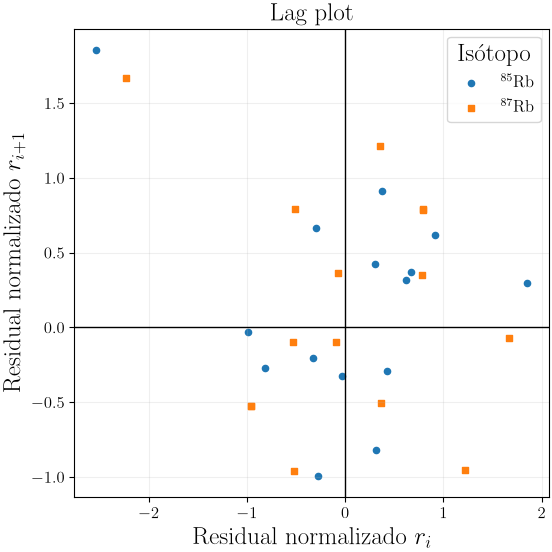

In [33]:
# FIGURA 2: LAG PLOT

plt.figure(figsize=(6,6))

plt.scatter(
    r85[:-1],
    r85[1:],
    s=20,
    color='tab:blue',
    marker='o',
    label=r'$^{85}$Rb'
)

plt.scatter(
    r87[:-1],
    r87[1:],
    s=20,
    color='tab:orange',
    marker='s',
    label=r'$^{87}$Rb'
)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.xlabel(r'Residual normalizado $r_i$')
plt.ylabel(r'Residual normalizado $r_{i+1}$')
plt.title('Lag plot')

plt.legend(title='Isótopo')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [34]:
from scipy.stats import t

n = len(f)
t95 = t.ppf(0.975, n-2)

IC85 = (
    m85 - t95*fit85.stderr,
    m85 + t95*fit85.stderr
)

IC87 = (
    m87 - t95*fit87.stderr,
    m87 + t95*fit87.stderr
)

print(f"IC 95% Rb-85 = [{IC85[0]:.2f}, {IC85[1]:.2f}] kHz/A")
print(f"IC 95% Rb-87 = [{IC87[0]:.2f}, {IC87[1]:.2f}] kHz/A")

IC 95% Rb-85 = [424.70, 433.95] kHz/A
IC 95% Rb-87 = [283.77, 287.74] kHz/A
